# Strategy 05 — Commission-Based TP/SL (Bybit)

Based on `03_strategy03_crypto_bybit.ipynb`.

**What changed vs. strategy 03:**
| Strategy 03 | Strategy 05 |
|-------------|-------------|
| TP = entry ± RR × swing-range | TP = entry ± 3 × total_commission |
| SL = entry ± swing-range | SL = entry ± 1 × total_commission |
| qty = risk_cash / sl_distance | qty = risk_cash / commission_distance |
| PnL = gross price movement | PnL = gross − commission |

**Commission math:**
```
commission_distance = entry_price × 2 × COMMISSION_RATE_PER_SIDE
SL distance  = 1 × commission_distance   (loss ≈ 1× commission)
TP distance  = 3 × commission_distance   (gain ≈ 3× commission, net ≈ 2×)
qty          = risk_cash / commission_distance
```

**Signal detection is unchanged** — EMA 8/13/21 on H1 for trend, swing H/L on M5 for entry level.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

_ROOT = Path.cwd().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

try:
    from dotenv import load_dotenv
    _env = _ROOT / ".env"
    if _env.exists():
        load_dotenv(_env)
except ImportError:
    pass

from strategy.crypto_core import EMA_FAST, EMA_MID, EMA_SLOW, default_crypto_tick

# ── User parameters ──────────────────────────────────────────────────────────
SYMBOL          = "BTCUSDT"
TF_ENTRY        = "M5"
TF_TREND        = "H1"

LOOKBACK_BARS        = 5
PENDING_OFFSET_TICKS = 3.0
PENDING_EXPIRY_MIN   = 60
PIP_SIZE             = default_crypto_tick(SYMBOL)
PENDING_OFFSET_PIPS  = float(PENDING_OFFSET_TICKS)

START_BALANCE  = 10_000.0
RISK_PER_TRADE = 0.01        # 1% of balance per trade

# Bybit Linear taker fee (stop entries and SL exits hit as taker)
COMMISSION_RATE_PER_SIDE = 0.00055   # 0.055 %
# TP orders can be set as limit (maker 0.02 %), but conservatively use taker here
# Change to 0.0002 for maker-TP assumption

BARS_M5 = 8000
BARS_H1 = 2000

CATEGORY = "linear"
TESTNET  = os.getenv("BYBIT_TESTNET", "false").lower() == "true"

TOTAL_FEE_RATE = 2 * COMMISSION_RATE_PER_SIDE  # entry + exit

print(f"Symbol={SYMBOL}  TF_TREND={TF_TREND}  TF_ENTRY={TF_ENTRY}")
print(f"PIP_SIZE={PIP_SIZE}  offset_ticks={PENDING_OFFSET_TICKS}")
print(f"Commission per side = {COMMISSION_RATE_PER_SIDE*100:.4f}%  "
      f"total = {TOTAL_FEE_RATE*100:.4f}%")
print(f"Testnet={TESTNET}")


Symbol=BTCUSDT  TF_TREND=H1  TF_ENTRY=M5
PIP_SIZE=1.0  offset_ticks=3.0
Commission per side = 0.0550%  total = 0.1100%
Testnet=False


In [2]:
# SECTION 2 — Load OHLCV from local cache (./data/SYMBOL/TIMEFRAME/ohlcv.csv)
DATA_DIR = _ROOT / "notebooks" / "data"
_TEHRAN  = "Asia/Tehran"


def _load_csv(symbol: str, tf: str, limit: int) -> pd.DataFrame:
    csv_path = DATA_DIR / symbol / tf / "ohlcv.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Cache file not found: {csv_path}\n"
            "Run 00_data_fetching_bybit.ipynb first."
        )
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize(_TEHRAN)
    df = df.sort_index()
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)
    df = df[["open", "high", "low", "close", "volume"]]
    if limit and len(df) > limit:
        df = df.iloc[-limit:]
    return df


def show_local(df, n=3):
    return df.tail(n).copy().set_index(df.tail(n).index.tz_convert(_TEHRAN))


print(f"Loading {TF_ENTRY} candles for {SYMBOL} ...")
m5 = _load_csv(SYMBOL, TF_ENTRY, limit=BARS_M5)
print(f"  -> {len(m5):,} rows  |  last: {m5.index[-1]}")

print(f"Loading {TF_TREND} candles for {SYMBOL} ...")
h1 = _load_csv(SYMBOL, TF_TREND, limit=BARS_H1)
print(f"  -> {len(h1):,} rows  |  last: {h1.index[-1]}")

display(show_local(m5))
display(show_local(h1))


Loading M5 candles for BTCUSDT ...
  -> 8,000 rows  |  last: 2026-05-14 19:40:00+03:30
Loading H1 candles for BTCUSDT ...
  -> 1,999 rows  |  last: 2026-05-14 18:30:00+03:30


,open,high,low,close,volume
time,,,,,
2026-05-14 19:30:00+03:30,81244.0,81462.0,81244.0,81285.3,1353.665
2026-05-14 19:35:00+03:30,81285.3,81444.4,81285.3,81424.5,369.072
2026-05-14 19:40:00+03:30,81424.5,81547.2,81416.7,81507.6,546.509


,open,high,low,close,volume
time,,,,,
2026-05-14 16:30:00+03:30,79724.0,80035.8,79622.0,79656.0,4229.640
2026-05-14 17:30:00+03:30,79656.0,80975.9,79515.5,80922.1,9290.666
2026-05-14 18:30:00+03:30,80922.1,81295.5,80743.3,81244.0,6601.728


In [3]:
# SECTION 3 — EMA 8/13/21
from strategy.crypto_core import add_emas

m5 = add_emas(m5)
h1 = add_emas(h1)

print("EMA columns added.")
display(h1[[f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))


EMA columns added.


,ema_8,ema_13,ema_21
time,,,
2026-05-14 14:30:00+03:30,79510.972241,79545.437803,79645.149061
2026-05-14 15:30:00+03:30,79558.311743,79570.946689,79652.317328
2026-05-14 16:30:00+03:30,79580.020244,79583.097162,79652.652116
2026-05-14 17:30:00+03:30,79878.260190,79774.383281,79768.056469
2026-05-14 18:30:00+03:30,80181.757926,79984.328527,79902.233154


In [4]:
# SECTION 4 — Merge H1 trend onto M5 (no lookahead)
from strategy.crypto_core import merge_h1_trend_onto_m5

m5_ctx = merge_h1_trend_onto_m5(m5, h1)

print(m5_ctx["trend"].value_counts(dropna=False))
display(m5_ctx[["close", "trend"]].tail(8))


trend
bull    3788
bear    2592
flat    1620
Name: count, dtype: int64


,close,trend
time,,
2026-05-14 19:05:00+03:30,80806.7,bull
2026-05-14 19:10:00+03:30,80974.9,bull
2026-05-14 19:15:00+03:30,81033.3,bull
2026-05-14 19:20:00+03:30,81243.7,bull
2026-05-14 19:25:00+03:30,81244.0,bull
2026-05-14 19:30:00+03:30,81285.3,bull
2026-05-14 19:35:00+03:30,81424.5,bull
2026-05-14 19:40:00+03:30,81507.6,bull


In [5]:
# SECTION 5 — Custom backtest engine with commission-based TP/SL

def _commission_setup(
    m5_ctx: pd.DataFrame,
    *,
    bar_index: int,
    lookback_bars: int,
    pending_offset_ticks: float,
    pip_size: float,
    risk_cash: float,
    commission_rate_per_side: float,
) -> dict | None:
    """
    Same signal detection as compute_pending_setup (EMA H1 trend + M5 swing).
    Overrides TP and SL with commission-based levels:
        SL distance = entry × 2 × commission_rate_per_side
        TP distance = 3 × SL distance
    """
    if bar_index < lookback_bars:
        return None

    row    = m5_ctx.iloc[bar_index]
    window = m5_ctx.iloc[bar_index - lookback_bars : bar_index]
    hh = float(window["high"].max())
    ll = float(window["low"].min())

    trend = row.get("trend", "flat")
    if trend not in ("bull", "bear"):
        return None

    offset         = float(pending_offset_ticks) * float(pip_size)
    total_fee_rate = 2.0 * commission_rate_per_side  # entry + exit

    if trend == "bull":
        entry     = hh + offset
        comm_dist = entry * total_fee_rate      # SL = 1× commission distance
        if comm_dist <= 0:
            return None
        sl  = entry - comm_dist
        tp  = entry + 3.0 * comm_dist           # TP = 3× commission distance
        qty = risk_cash / comm_dist
        return {"side": "buy",  "entry": entry, "sl": sl, "tp": tp,
                "qty": qty, "comm_dist": comm_dist}

    # bear
    entry     = ll - offset
    comm_dist = entry * total_fee_rate
    if comm_dist <= 0:
        return None
    sl  = entry + comm_dist
    tp  = entry - 3.0 * comm_dist
    qty = risk_cash / comm_dist
    return {"side": "sell", "entry": entry, "sl": sl, "tp": tp,
            "qty": qty, "comm_dist": comm_dist}


def run_backtest_commission(
    data: pd.DataFrame,
    *,
    start_balance: float,
    lookback_bars: int,
    pending_offset_ticks: float,
    pip_size: float,
    risk_per_trade: float,
    pending_expiry_min: int,
    commission_rate_per_side: float,
    entry_timeframe_minutes: int = 5,
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Walk-forward backtest using commission-based TP/SL.
    PnL column is NET of exchange commission.
    SL takes priority when both SL and TP are hit on the same candle.
    """
    data        = data.copy().sort_index()
    expiry_bars = max(1, int(pending_expiry_min / entry_timeframe_minutes))

    trades: list[dict] = []
    balance = float(start_balance)
    equity_pts: list[tuple] = []

    pending:  dict | None = None
    position: dict | None = None

    for i in range(lookback_bars, len(data)):
        idx = data.index[i]
        row = data.iloc[i]

        # ── Equity snapshot ───────────────────────────────────────────────
        floating = 0.0
        if position is not None:
            if position["side"] == "buy":
                floating = (row["close"] - position["entry"]) * position["qty"]
            else:
                floating = (position["entry"] - row["close"]) * position["qty"]
        equity_pts.append((idx, balance + floating))

        # ── Check open position ───────────────────────────────────────────
        if position is not None:
            hit_sl = hit_tp = False
            if position["side"] == "buy":
                hit_sl = row["low"]  <= position["sl"]
                hit_tp = row["high"] >= position["tp"]
            else:
                hit_sl = row["high"] >= position["sl"]
                hit_tp = row["low"]  <= position["tp"]

            if hit_sl or hit_tp:
                exit_price = position["sl"] if hit_sl else position["tp"]
                gross_pnl  = (exit_price - position["entry"]) * position["qty"]
                if position["side"] == "sell":
                    gross_pnl = -gross_pnl

                # Actual exchange commission (taker both sides)
                commission = (
                    position["entry"] * position["qty"] * commission_rate_per_side
                    + exit_price      * position["qty"] * commission_rate_per_side
                )
                net_pnl = gross_pnl - commission

                balance += net_pnl
                trades.append({
                    "entry_time":    position["entry_time"],
                    "exit_time":     idx,
                    "side":          position["side"],
                    "entry":         position["entry"],
                    "sl":            position["sl"],
                    "tp":            position["tp"],
                    "exit":          exit_price,
                    "qty":           round(position["qty"], 6),
                    "comm_dist":     round(position["comm_dist"], 4),
                    "gross_pnl":     round(gross_pnl, 4),
                    "commission":    round(commission, 4),
                    "pnl":           round(net_pnl, 4),
                    "balance_after": round(balance, 4),
                    "result":        "win" if net_pnl > 0 else "loss",
                })
                position = None
            continue

        # ── Check pending order ───────────────────────────────────────────
        if pending is not None:
            age = i - pending["created_i"]
            if age > expiry_bars:
                pending = None
            else:
                triggered = (
                    (pending["side"] == "buy"  and row["high"] >= pending["entry"]) or
                    (pending["side"] == "sell" and row["low"]  <= pending["entry"])
                )
                if triggered:
                    position = {
                        "side":       pending["side"],
                        "entry":      pending["entry"],
                        "sl":         pending["sl"],
                        "tp":         pending["tp"],
                        "qty":        pending["qty"],
                        "comm_dist":  pending["comm_dist"],
                        "entry_time": idx,
                    }
                    pending = None

        # ── Generate new pending signal ───────────────────────────────────
        if pending is None and position is None:
            risk_cash = balance * risk_per_trade
            setup = _commission_setup(
                data,
                bar_index=i,
                lookback_bars=lookback_bars,
                pending_offset_ticks=pending_offset_ticks,
                pip_size=pip_size,
                risk_cash=risk_cash,
                commission_rate_per_side=commission_rate_per_side,
            )
            if setup is not None:
                pending = {**setup, "created_i": i}

    trades_df = pd.DataFrame(trades)
    eq = pd.Series({t: v for t, v in equity_pts}).sort_index()
    return trades_df, eq


print("Engine defined. Running backtest...")

trades_df, equity_curve = run_backtest_commission(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    commission_rate_per_side=COMMISSION_RATE_PER_SIDE,
    entry_timeframe_minutes=5,
)

print(f"Total trades: {len(trades_df)}")
display(trades_df.tail(10))


Engine defined. Running backtest...
Total trades: 370


,entry_time,exit_time,side,entry,sl,tp,exit,qty,comm_dist,gross_pnl,commission,pnl,balance_after,result
360,2026-05-14 06:20:00+03:30,2026-05-14 06:35:00+03:30,sell,79369.6,79456.90656,79107.68032,79107.68032,0.064778,87.3066,16.9667,5.6462,11.3204,576.8760,win
361,2026-05-14 06:50:00+03:30,2026-05-14 06:55:00+03:30,sell,79098.7,79185.70857,78837.67429,79185.70857,0.066301,87.0086,-5.7688,5.7719,-11.5407,565.3353,loss
362,2026-05-14 07:25:00+03:30,2026-05-14 07:35:00+03:30,sell,78949.5,79036.34445,78688.96665,79036.34445,0.065097,86.8445,-5.6534,5.6565,-11.3098,554.0255,loss
363,2026-05-14 13:35:00+03:30,2026-05-14 13:40:00+03:30,sell,79525.0,79612.47750,79262.56750,79612.47750,0.063333,87.4775,-5.5403,5.5433,-11.0836,542.9420,loss
364,2026-05-14 14:10:00+03:30,2026-05-14 14:55:00+03:30,sell,79515.3,79602.76683,79252.89951,79252.89951,0.062074,87.4668,16.2883,5.4205,10.8678,553.8098,win
365,2026-05-14 15:15:00+03:30,2026-05-14 15:30:00+03:30,sell,79224.2,79311.34662,78962.76014,79311.34662,0.063549,87.1466,-5.5381,5.5411,-11.0792,542.7305,loss
366,2026-05-14 17:45:00+03:30,2026-05-14 18:10:00+03:30,buy,80017.0,79928.98130,80281.05610,80281.05610,0.061661,88.0187,16.2819,5.4363,10.8457,553.5762,win
367,2026-05-14 18:20:00+03:30,2026-05-14 18:25:00+03:30,buy,80337.5,80249.12875,80602.61375,80602.61375,0.062642,88.3713,16.6073,5.5449,11.0624,564.6386,win
368,2026-05-14 18:35:00+03:30,2026-05-14 18:40:00+03:30,buy,80978.9,80889.82321,81246.13037,80889.82321,0.063388,89.0768,-5.6464,5.6433,-11.2897,553.3489,loss
369,2026-05-14 19:20:00+03:30,2026-05-14 19:30:00+03:30,buy,81122.2,81032.96558,81389.90326,81389.90326,0.062011,89.2344,16.6005,5.5426,11.0578,564.4067,win


In [6]:
# SECTION 5b — All pending signals (not filtered by expiry / position overlap)

def list_commission_signals(
    data: pd.DataFrame,
    *,
    risk_cash: float,
    lookback_bars: int,
    pending_offset_ticks: float,
    pip_size: float,
    commission_rate_per_side: float,
) -> pd.DataFrame:
    data = data.copy().sort_index()
    rows: list[dict] = []
    for i in range(lookback_bars, len(data)):
        setup = _commission_setup(
            data,
            bar_index=i,
            lookback_bars=lookback_bars,
            pending_offset_ticks=pending_offset_ticks,
            pip_size=pip_size,
            risk_cash=risk_cash,
            commission_rate_per_side=commission_rate_per_side,
        )
        if setup is None:
            continue
        rows.append({
            "signal_bar_index": i,
            "signal_bar_time":  data.index[i],
            "trend":            data.iloc[i].get("trend", "flat"),
            "side":             setup["side"],
            "entry":            setup["entry"],
            "sl":               setup["sl"],
            "tp":               setup["tp"],
            "comm_dist":        setup["comm_dist"],
            "qty":              setup["qty"],
        })
    return pd.DataFrame(rows)


signals_df = list_commission_signals(
    m5_ctx,
    risk_cash=START_BALANCE * RISK_PER_TRADE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    commission_rate_per_side=COMMISSION_RATE_PER_SIDE,
)

print(f"Total signals generated: {len(signals_df)}")
print(f"\nSample commission distance for {SYMBOL}:")
if not signals_df.empty:
    sample = signals_df.iloc[-1]
    print(f"  Entry        = {sample['entry']:.2f}")
    print(f"  Comm dist    = {sample['comm_dist']:.4f}  "
          f"({TOTAL_FEE_RATE*100:.3f}% of entry)")
    print(f"  SL distance  = {sample['comm_dist']:.4f}")
    print(f"  TP distance  = {3*sample['comm_dist']:.4f}")

display(signals_df.tail(10))


Total signals generated: 6375

Sample commission distance for BTCUSDT:
  Entry        = 81465.00
  Comm dist    = 89.6115  (0.110% of entry)
  SL distance  = 89.6115
  TP distance  = 268.8345


,signal_bar_index,signal_bar_time,trend,side,entry,sl,tp,comm_dist,qty
6365,7990,2026-05-14 18:55:00+03:30,bull,buy,81122.2,81032.96558,81389.90326,89.23442,1.120644
6366,7991,2026-05-14 19:00:00+03:30,bull,buy,81103.0,81013.78670,81370.63990,89.21330,1.120909
6367,7992,2026-05-14 19:05:00+03:30,bull,buy,81103.0,81013.78670,81370.63990,89.21330,1.120909
6368,7993,2026-05-14 19:10:00+03:30,bull,buy,81103.0,81013.78670,81370.63990,89.21330,1.120909
6369,7994,2026-05-14 19:15:00+03:30,bull,buy,81103.0,81013.78670,81370.63990,89.21330,1.120909
6370,7995,2026-05-14 19:20:00+03:30,bull,buy,81036.3,80947.16007,81303.71979,89.13993,1.121832
6371,7996,2026-05-14 19:25:00+03:30,bull,buy,81270.0,81180.60300,81538.19100,89.39700,1.118606
6372,7997,2026-05-14 19:30:00+03:30,bull,buy,81298.5,81209.07165,81566.78505,89.42835,1.118214
6373,7998,2026-05-14 19:35:00+03:30,bull,buy,81465.0,81375.38850,81733.83450,89.61150,1.115928
6374,7999,2026-05-14 19:40:00+03:30,bull,buy,81465.0,81375.38850,81733.83450,89.61150,1.115928


In [7]:
# SECTION 6 — Metrics

def max_drawdown_pct(equity) -> float:
    eq = pd.Series(equity).astype(float).dropna()
    if len(eq) < 2:
        return 0.0
    peak = eq.cummax()
    dd   = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize(trades: pd.DataFrame, start_balance: float, equity=None) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{
            "trades": 0, "win_rate_%": 0, "gross_pnl": 0, "net_pnl": 0,
            "total_commission": 0, "profit_factor": None,
            "max_drawdown_%": 0, "start_balance": start_balance,
            "end_balance": start_balance, "return_%": 0,
        }])

    wins   = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]
    gp = wins.sum()   if not wins.empty   else 0.0
    gl = abs(losses.sum()) if not losses.empty else 0.0
    pf = gp / gl if gl > 0 else np.nan
    end_b = float(trades["balance_after"].iloc[-1])

    return pd.DataFrame([{
        "trades":           int(len(trades)),
        "win_rate_%":       round((trades["pnl"] > 0).mean() * 100, 2),
        "gross_pnl":        round(trades["gross_pnl"].sum(), 2),
        "total_commission": round(trades["commission"].sum(), 2),
        "net_pnl":          round(trades["pnl"].sum(), 2),
        "avg_net_pnl":      round(trades["pnl"].mean(), 4),
        "profit_factor":    round(float(pf), 3) if pd.notna(pf) else np.nan,
        "max_drawdown_%":   round(max_drawdown_pct(equity), 2),
        "start_balance":    round(start_balance, 2),
        "end_balance":      round(end_b, 2),
        "return_%":         round(((end_b / start_balance) - 1) * 100, 4),
    }])


if not trades_df.empty:
    trades_df["cumulative_net_pnl"] = trades_df["pnl"].cumsum()

summary = summarize(trades_df, START_BALANCE, equity_curve)
display(summary)

# ── Per-side breakdown ────────────────────────────────────────────────────────
if not trades_df.empty:
    print("\nPer-side breakdown:")
    display(
        trades_df.groupby("side").agg(
            trades=("pnl", "count"),
            win_rate=("pnl", lambda x: (x > 0).mean()),
            net_pnl=("pnl", "sum"),
            gross_pnl=("gross_pnl", "sum"),
            commission=("commission", "sum"),
        ).round(4)
    )


,trades,win_rate_%,gross_pnl,total_commission,net_pnl,avg_net_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,370,31.08,1394.61,10830.21,-9435.59,-25.5016,0.393,94.6,10000.0,564.41,-94.3559



Per-side breakdown:


,trades,win_rate,net_pnl,gross_pnl,commission
side,,,,,
buy,210,0.3238,-5803.6911,882.7258,6686.4158
sell,160,0.2938,-3631.9025,511.8886,4143.7906


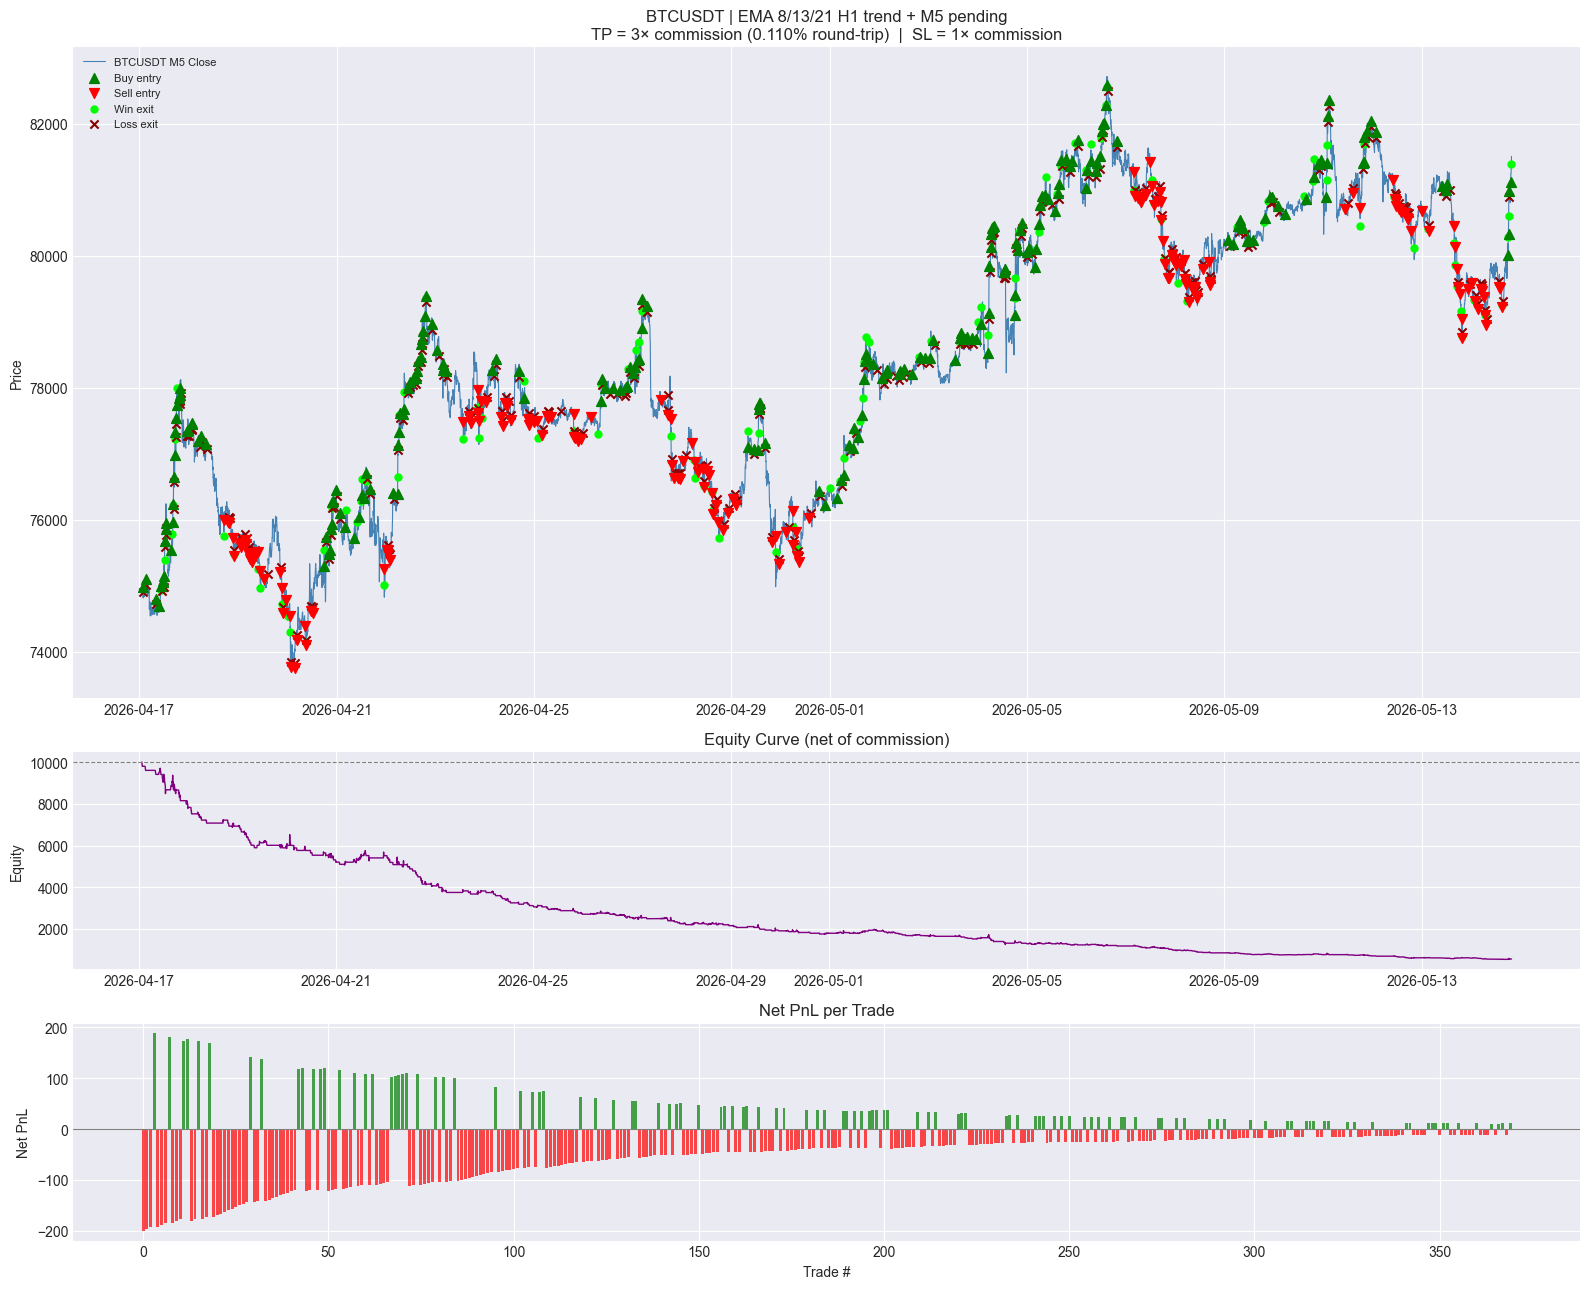

In [8]:
# SECTION 7 — Charts
fig, axes = plt.subplots(3, 1, figsize=(16, 13),
                         gridspec_kw={"height_ratios": [3, 1, 1]})
ax_price, ax_eq, ax_pnl = axes

ax_price.plot(m5_ctx.index, m5_ctx["close"],
              label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=0.8)

if not trades_df.empty:
    buys  = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]
    ax_price.scatter(buys["entry_time"],  buys["entry"],
                     marker="^", color="green",   s=50, label="Buy entry",  zorder=5)
    ax_price.scatter(sells["entry_time"], sells["entry"],
                     marker="v", color="red",     s=50, label="Sell entry", zorder=5)
    wins_mask  = trades_df["pnl"] > 0
    ax_price.scatter(trades_df[wins_mask]["exit_time"],
                     trades_df[wins_mask]["exit"],
                     marker="o", color="lime",    s=25, label="Win exit",   zorder=4)
    ax_price.scatter(trades_df[~wins_mask]["exit_time"],
                     trades_df[~wins_mask]["exit"],
                     marker="x", color="darkred", s=35, label="Loss exit",  zorder=4)

total_fee_pct = TOTAL_FEE_RATE * 100
ax_price.set_title(
    f"{SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} H1 trend + M5 pending\n"
    f"TP = 3× commission ({total_fee_pct:.3f}% round-trip)  |  "
    f"SL = 1× commission"
)
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left", fontsize=8)

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.0)
ax_eq.axhline(START_BALANCE, color="gray", linestyle="--", linewidth=0.8)
ax_eq.set_title("Equity Curve (net of commission)")
ax_eq.set_ylabel("Equity")

if not trades_df.empty:
    colors = ["green" if p > 0 else "red" for p in trades_df["pnl"]]
    ax_pnl.bar(range(len(trades_df)), trades_df["pnl"], color=colors, alpha=0.7)
    ax_pnl.axhline(0, color="gray", linewidth=0.8)
ax_pnl.set_title("Net PnL per Trade")
ax_pnl.set_ylabel("Net PnL")
ax_pnl.set_xlabel("Trade #")

plt.tight_layout()
plt.show()


In [9]:
# SECTION 8 — Save results
RESULT_DIR = Path("./results") / "strategy05_commission_tpsl" / SYMBOL / TF_ENTRY
RESULT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(RESULT_DIR / "metrics.csv", index=False)

if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time", "exit_time", "side", "entry", "sl", "tp", "exit",
        "qty", "comm_dist", "gross_pnl", "commission", "pnl",
        "balance_after", "result", "cumulative_net_pnl"
    ]).to_csv(RESULT_DIR / "trades.csv", index=False)
else:
    trades_df.to_csv(RESULT_DIR / "trades.csv", index=False)

if not signals_df.empty:
    signals_df.to_csv(RESULT_DIR / "signals.csv", index=False)

print(f"Saved -> {RESULT_DIR}")
print(f"  metrics.csv  ({len(summary)} row)")
print(f"  trades.csv   ({len(trades_df)} rows)")
print(f"  signals.csv  ({len(signals_df)} rows)")


Saved -> results\strategy05_commission_tpsl\BTCUSDT\M5
  metrics.csv  (1 row)
  trades.csv   (370 rows)
  signals.csv  (6375 rows)


## Notes

### Commission math
| Item | Formula | Example (BTC @ 80 000) |
|------|---------|------------------------|
| `commission_distance` | `entry × 2 × rate` | 80 000 × 0.0011 = **88 USDT** |
| SL distance | `1 × commission_distance` | **88 USDT** |
| TP distance | `3 × commission_distance` | **264 USDT** |
| `qty` | `risk_cash / commission_distance` | 100 / 88 ≈ **1.136 BTC** |
| Gross PnL at TP | `3 × risk_cash` | **300 USDT** |
| Commission paid | `≈ 2 × risk_cash` | **200 USDT** |
| **Net PnL at TP** | `≈ 2 × risk_cash` | **≈ 200 USDT** |
| **Net PnL at SL** | `≈ -2 × risk_cash` | **≈ -200 USDT** |

> **Net break-even win rate ≈ 50%** (gross 3:1 RR collapses to 1:1 net after commission).
> The strategy is profitable when win rate > 50%.

### Adjustable parameters
- `COMMISSION_RATE_PER_SIDE` — use `0.0002` (maker) if TP orders are placed as limit.
- `RISK_PER_TRADE` — fraction of balance risked (gross) per trade.
- `PENDING_EXPIRY_MIN` — how long a pending order stays active before cancellation.

### Comparison with Strategy 03
Strategy 03 uses a swing-based SL (wider, position-sized to 1% risk on that swing distance).  
Strategy 05 uses a tiny commission-distance SL → higher qty → higher leverage per trade.  
Expected behaviour: more trades fill (tighter TP closer to market), shorter hold times,  
larger position sizes, and results dominated by win-rate rather than RR.
